In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import plotly.express as px
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
df=pd.read_csv("cricket_knn_indian_players.csv")
df.head()

,temperature,wind_speed,opposition_strength,pitch_dry,pitch_dusty,pitch_green,pitch_hard,best_batter
0,16.637259,4.421072,8,True,False,False,False,1
1,29.622614,24.041788,2,True,False,False,False,1
2,33.223549,11.592342,6,False,False,True,False,3
3,20.340980,8.765273,7,True,False,False,False,1
4,24.992762,26.830270,3,True,False,False,False,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          500 non-null    float64
 1   wind_speed           500 non-null    float64
 2   opposition_strength  500 non-null    int64  
 3   pitch_dry            500 non-null    bool   
 4   pitch_dusty          500 non-null    bool   
 5   pitch_green          500 non-null    bool   
 6   pitch_hard           500 non-null    bool   
 7   best_batter          500 non-null    int64  
dtypes: bool(4), float64(2), int64(2)
memory usage: 17.7 KB


In [4]:
df.describe()

,temperature,wind_speed,opposition_strength,best_batter
count,500.000000,500.000000,500.000000,500.000000
mean,28.190181,14.391245,5.534000,1.920000
std,7.341662,8.731447,2.808669,0.995783
min,15.124362,0.012521,1.000000,1.000000
25%,22.011719,6.847114,3.000000,1.000000
50%,29.164127,13.741180,6.000000,1.000000
75%,34.596359,21.687565,8.000000,3.000000
max,39.811802,29.954862,10.000000,5.000000


In [5]:
df.columns

Index(['temperature', 'wind_speed', 'opposition_strength', 'pitch_dry',
       'pitch_dusty', 'pitch_green', 'pitch_hard', 'best_batter'],
      dtype='object')

In [6]:
df["best_batter"].value_counts()

best_batter
1    266
3    223
2     10
5      1
Name: count, dtype: int64

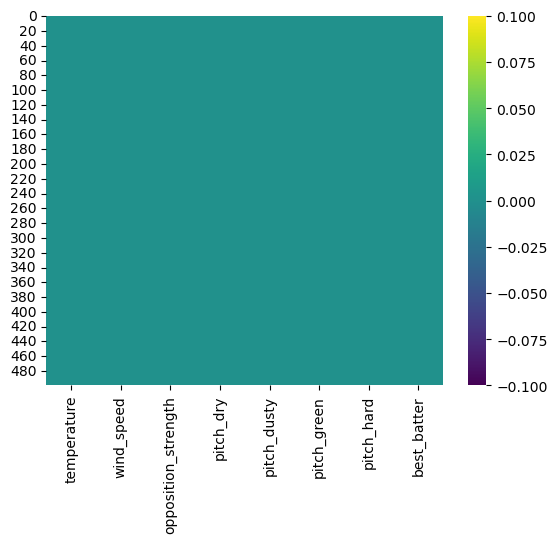

In [7]:
sb.heatmap(df.isnull(), cbar=True, cmap="viridis")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("best_batter", axis=1)
y = df["best_batter"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
from sklearn.neighbors import KNeighborsClassifier

a=[]
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    a.append((knn.score(X_test, y_test),i))
kmax=max(a)
print("best k value:", kmax[1])

best k value: 6


In [18]:
knn = KNeighborsClassifier(n_neighbors=kmax[1])
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_logreg = log_reg.predict(X_test)

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_knn = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

[[40  0 18]
 [ 1  0  1]
 [17  0 23]]
              precision    recall  f1-score   support

           1       0.69      0.69      0.69        58
           2       0.00      0.00      0.00         2
           3       0.55      0.57      0.56        40

    accuracy                           0.63       100
   macro avg       0.41      0.42      0.42       100
weighted avg       0.62      0.63      0.62       100



c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


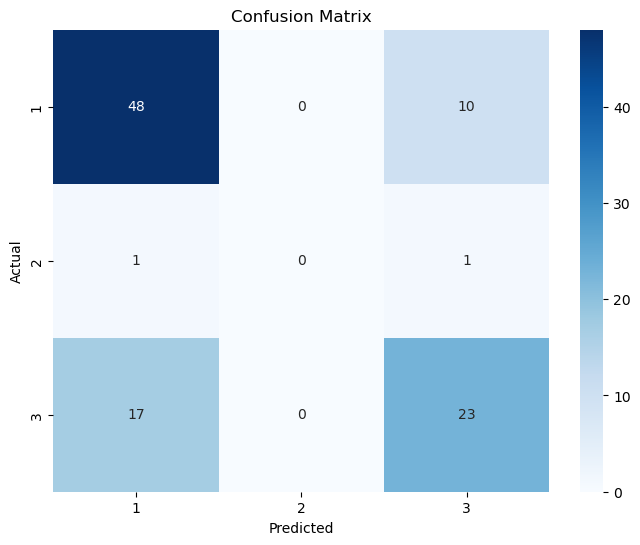

In [21]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


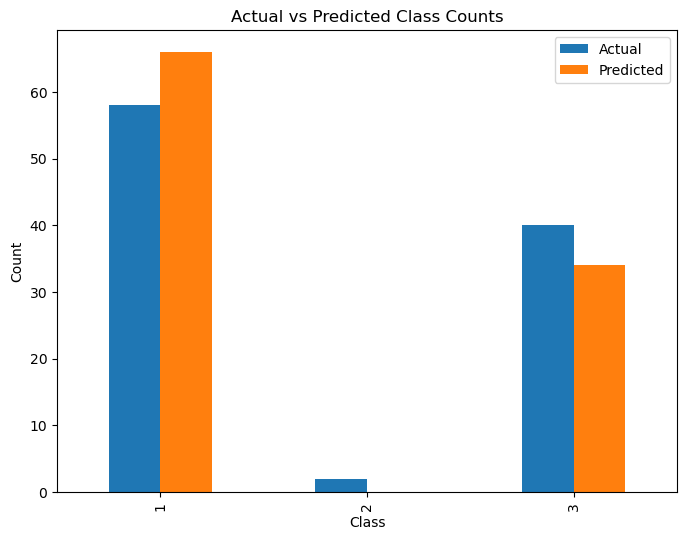

In [22]:
# Bar plot: Actual vs Predicted class counts
actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
df_counts = pd.DataFrame({'Actual': actual_counts, 'Predicted': pred_counts})
df_counts.plot(kind='bar', figsize=(8,6))
plt.title('Actual vs Predicted Class Counts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [39]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
# y_pred_knn, y_pred_logreg, y_pred_nb should be predictions from each model
    results = []

    # KNN
    results.append({
        'Model': 'KNN',
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'F1_macro': f1_score(y_test, y_pred_knn, average='macro'),
        'F1_weighted': f1_score(y_test, y_pred_knn, average='weighted')
    })
    print('KNN Classification Report:')
    print(classification_report(y_test, y_pred_knn))

    # Logistic Regression
    results.append({
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_logreg),
        'F1_macro': f1_score(y_test, y_pred_logreg, average='macro'),
        'F1_weighted': f1_score(y_test, y_pred_logreg, average='weighted')
    })
    print('Logistic Regression Classification Report:')
    print(classification_report(y_test, y_pred_logreg))

    # Naive Bayes
    results.append({
        'Model': 'Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'F1_macro': f1_score(y_test, y_pred_nb, average='macro'),
        'F1_weighted': f1_score(y_test, y_pred_nb, average='weighted')
    })
    print('Naive Bayes Classification Report:')
    print(classification_report(y_test, y_pred_nb))

    # Summary Table
    df_results = pd.DataFrame(results)
    print('\nModel Comparison:')
    print(df_results)

KNN Classification Report:
              precision    recall  f1-score   support

           1       0.69      0.69      0.69        58
           2       0.00      0.00      0.00         2
           3       0.55      0.57      0.56        40

    accuracy                           0.63       100
   macro avg       0.41      0.42      0.42       100
weighted avg       0.62      0.63      0.62       100

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.69      0.73        58
           2       0.00      0.00      0.00         2
           3       0.58      0.70      0.64        40

    accuracy                           0.68       100
   macro avg       0.45      0.46      0.45       100
weighted avg       0.68      0.68      0.68       100

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.48      0.60        58
           2       0.06 

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\anaconda3\Lib\site-packag